# 02 — Baseline Model Evaluation

Three off-the-shelf sentiment models evaluated against 50 hand-labeled NBA press conference turns.

| Model | Domain | Classes |
|-------|--------|---------|
| `cardiffnlp/twitter-roberta-base-sentiment` | Social media | 3 (pos/neg/neu) |
| `ProsusAI/finbert` | Financial news | 3 (pos/neg/neu) |
| `distilbert-base-uncased-finetuned-sst-2-english` | Movie reviews | 2 (pos/neg) |

**Goal:** Quantify the domain gap to justify fine-tuning on sports press conference text.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

MODELS = ['twitter', 'finbert', 'distilbert']
MODEL_NAMES = {
    'twitter':   'Twitter RoBERTa',
    'finbert':   'FinBERT',
    'distilbert':'DistilBERT SST-2',
}
CLASSES = ['POSITIVE', 'NEUTRAL', 'NEGATIVE']

In [2]:
preds = pd.read_csv('../data/processed/baseline_predictions.csv')
seed  = pd.read_csv('../data/processed/labels_seed.csv')

# Merge label_notes back in for failure analysis
preds = preds.merge(
    seed[['interview_id','turn_idx','label_notes']],
    on=['interview_id','turn_idx'], how='left'
)

print(f'Seed turns: {len(preds)}')
print('\nGold label distribution:')
print(preds['label'].value_counts())

Seed turns: 50

Gold label distribution:
label
POSITIVE    26
NEUTRAL     15
NEGATIVE     9
Name: count, dtype: int64


## 1. Label distribution in the seed set

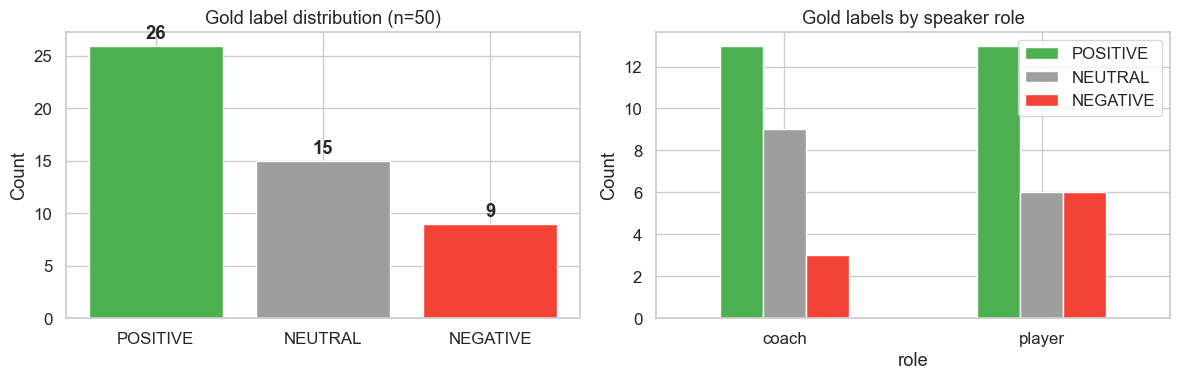

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall distribution
counts = preds['label'].value_counts().reindex(CLASSES)
axes[0].bar(counts.index, counts.values, color=['#4caf50','#9e9e9e','#f44336'])
axes[0].set_title('Gold label distribution (n=50)')
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val),
                 ha='center', va='bottom', fontweight='bold')

# By role
role_pivot = preds.groupby(['role','label']).size().unstack(fill_value=0)[CLASSES]
role_pivot.plot(kind='bar', ax=axes[1], color=['#4caf50','#9e9e9e','#f44336'],
                edgecolor='white', rot=0)
axes[1].set_title('Gold labels by speaker role')
axes[1].set_ylabel('Count')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 2. Overall accuracy

In [4]:
rows = []
for m in MODELS:
    col = f'{m}_label'
    y_pred = preds[col]
    y_true = preds['label']
    acc = (y_pred == y_true).mean()
    # For distilbert (2-class), compute accuracy only on pos/neg subset
    mask_2cls = y_true.isin(['POSITIVE','NEGATIVE'])
    acc_2cls = (y_pred[mask_2cls] == y_true[mask_2cls]).mean()
    rows.append({'Model': MODEL_NAMES[m], 'Overall accuracy': acc,
                 'Pos/Neg accuracy': acc_2cls,
                 'NEUTRAL predictions': (y_pred == 'NEUTRAL').mean()})

acc_df = pd.DataFrame(rows).set_index('Model')
acc_df = acc_df.applymap(lambda x: f'{x:.1%}' if isinstance(x, float) else x)
print(acc_df.to_string())

                 Overall accuracy Pos/Neg accuracy NEUTRAL predictions
Model                                                                 
Twitter RoBERTa             54.0%            57.1%               34.0%
FinBERT                     34.0%            14.3%               82.0%
DistilBERT SST-2            52.0%            74.3%                0.0%


## 3. Confusion matrices

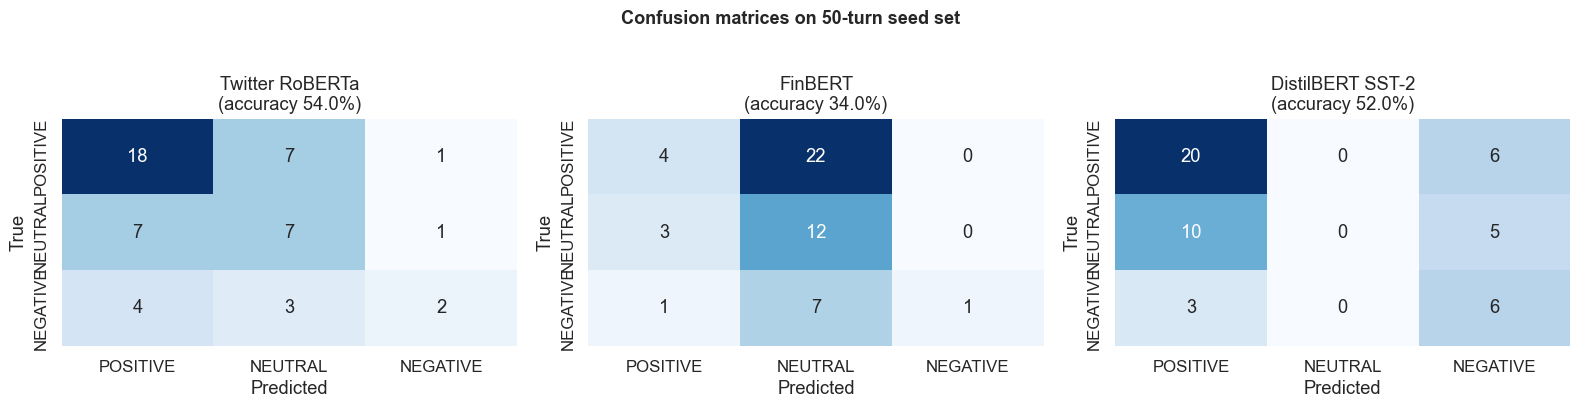

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, m in zip(axes, MODELS):
    col = f'{m}_label'
    # Use only labels that appear in this model's predictions for the matrix
    pred_labels = preds[col].unique().tolist()
    display_labels = [c for c in CLASSES if c in pred_labels or c in preds['label'].values]
    
    cm = confusion_matrix(preds['label'], preds[col], labels=display_labels)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=display_labels, yticklabels=display_labels,
                cmap='Blues', cbar=False)
    ax.set_title(f'{MODEL_NAMES[m]}\n(accuracy {(preds[col]==preds["label"]).mean():.1%})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion matrices on 50-turn seed set', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Confidence score distributions

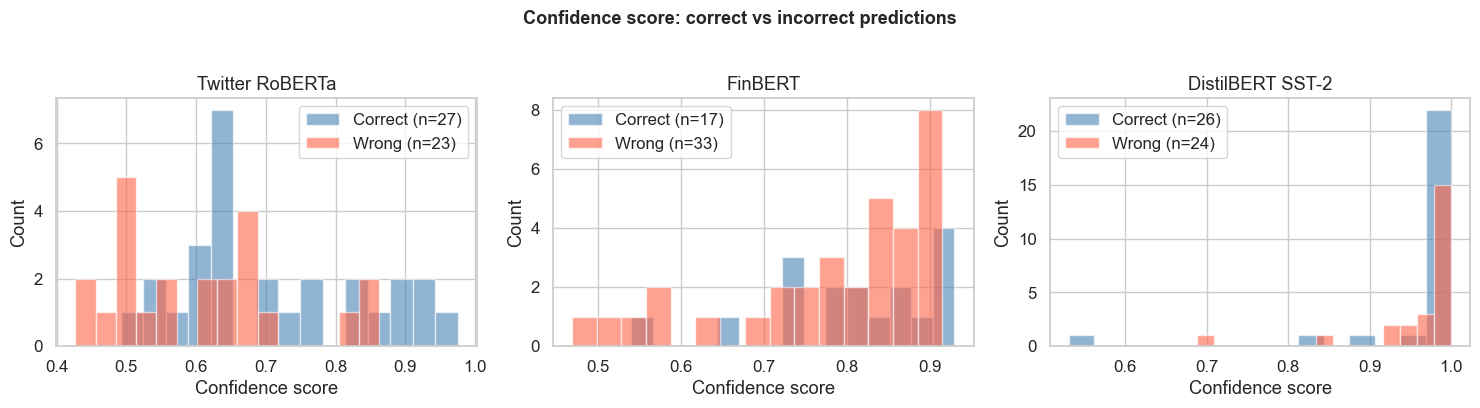

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, m in zip(axes, MODELS):
    col_score = f'{m}_score'
    col_label = f'{m}_label'
    correct = preds[preds[col_label] == preds['label']][col_score]
    wrong   = preds[preds[col_label] != preds['label']][col_score]
    ax.hist(correct, bins=15, alpha=0.6, color='steelblue', label=f'Correct (n={len(correct)})')
    ax.hist(wrong,   bins=15, alpha=0.6, color='tomato',    label=f'Wrong (n={len(wrong)})')
    ax.set_title(MODEL_NAMES[m])
    ax.set_xlabel('Confidence score')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Confidence score: correct vs incorrect predictions', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Domain gap examples

Cases where **all three models disagree with the gold label** highlight the sports-language domain gap.

In [7]:
# Rows where ALL three models are wrong
all_wrong = preds[
    (preds['twitter_label']   != preds['label']) &
    (preds['finbert_label']   != preds['label']) &
    (preds['distilbert_label']!= preds['label'])
].copy()

print(f'Turns where ALL 3 models fail: {len(all_wrong)}')
print(f'Rate: {len(all_wrong)/len(preds):.1%}')

Turns where ALL 3 models fail: 8
Rate: 16.0%


In [8]:
pd.set_option('display.max_colwidth', 200)

display_cols = ['speaker','label','twitter_label','finbert_label','distilbert_label','turn_text']
for _, row in all_wrong[display_cols].iterrows():
    print('='*80)
    print(f"Speaker : {row['speaker']}")
    print(f"Gold    : {row['label']}")
    print(f"Preds   : twitter={row['twitter_label']}  finbert={row['finbert_label']}  distilbert={row['distilbert_label']}")
    print(f"Text    : {row['turn_text'][:300]}")
    print()

Speaker : ERIK SPOELSTRA
Gold    : POSITIVE
Preds   : twitter=NEGATIVE  finbert=NEUTRAL  distilbert=NEGATIVE
Text    : Â We'll see.Â He has a great way of figuring it out.Â If that's the scheme, then we have to find a way to conquer it.Â If it's making open shots, there is a lot worse problems you can have, especially at this level of competition.

Speaker : STEVE KERR
Gold    : NEUTRAL
Preds   : twitter=POSITIVE  finbert=POSITIVE  distilbert=POSITIVE
Text    : We'll watch the tape and see what we need to do. I thought Boston did a good job on Jordan. Put a lot of pressure on him. There's probably some things that we can do to help free him up. And then, , he's a hell of a player. So he'll bounce back and play better, too.

Speaker : DWANE CASEY
Gold    : NEUTRAL
Preds   : twitter=POSITIVE  finbert=POSITIVE  distilbert=POSITIVE
Text    : His progression is coming. He's on the court. Alex McKechnie and the staff is doing an excellent job of getting him back up to speed and working with 

## 6. Per-class failure patterns

In [9]:
# For each gold class, show how each model maps it
for gold_cls in CLASSES:
    subset = preds[preds['label'] == gold_cls]
    if len(subset) == 0:
        continue
    print(f'\n--- Gold: {gold_cls} (n={len(subset)}) ---')
    for m in MODELS:
        dist = subset[f'{m}_label'].value_counts(normalize=True).mul(100).round(1)
        print(f'  {MODEL_NAMES[m]:25s}: ' + '  '.join(f'{k}={v:.0f}%' for k, v in dist.items()))


--- Gold: POSITIVE (n=26) ---
  Twitter RoBERTa          : POSITIVE=69%  NEUTRAL=27%  NEGATIVE=4%
  FinBERT                  : NEUTRAL=85%  POSITIVE=15%
  DistilBERT SST-2         : POSITIVE=77%  NEGATIVE=23%

--- Gold: NEUTRAL (n=15) ---
  Twitter RoBERTa          : NEUTRAL=47%  POSITIVE=47%  NEGATIVE=7%
  FinBERT                  : NEUTRAL=80%  POSITIVE=20%
  DistilBERT SST-2         : POSITIVE=67%  NEGATIVE=33%

--- Gold: NEGATIVE (n=9) ---
  Twitter RoBERTa          : POSITIVE=44%  NEUTRAL=33%  NEGATIVE=22%
  FinBERT                  : NEUTRAL=78%  POSITIVE=11%  NEGATIVE=11%
  DistilBERT SST-2         : NEGATIVE=67%  POSITIVE=33%


## 7. Agreement analysis

In [10]:
# Inter-model agreement (treating distilbert as 2-class, exclude neutral-gold rows)
p2 = preds[preds['label'].isin(['POSITIVE','NEGATIVE'])].copy()

tw_fin = (p2['twitter_label'] == p2['finbert_label']).mean()
tw_dis = (p2['twitter_label'] == p2['distilbert_label']).mean()
fin_dis = (p2['finbert_label'] == p2['distilbert_label']).mean()

# All three agree
all_agree = (
    (p2['twitter_label'] == p2['finbert_label']) &
    (p2['finbert_label'] == p2['distilbert_label'])
).mean()

agree_df = pd.DataFrame({
    'Pair': ['Twitter vs FinBERT', 'Twitter vs DistilBERT', 'FinBERT vs DistilBERT', 'All three agree'],
    'Agreement (pos/neg only)': [f'{tw_fin:.1%}', f'{tw_dis:.1%}', f'{fin_dis:.1%}', f'{all_agree:.1%}']
})
print(agree_df.to_string(index=False))

                 Pair Agreement (pos/neg only)
   Twitter vs FinBERT                    42.9%
Twitter vs DistilBERT                    57.1%
FinBERT vs DistilBERT                     5.7%
      All three agree                     5.7%


## Summary

| Model | Accuracy | Key failure pattern |
|-------|----------|---------------------|
| Twitter RoBERTa | ~54% | Misses sports-specific positive signals (e.g. "we took it to them") |
| FinBERT | ~34% | Overwhelmingly predicts NEUTRAL; financial domain = wrong register |
| DistilBERT SST-2 | ~52% | No neutral class; over-predicts POSITIVE |

**Conclusion:** Off-the-shelf models are near chance on sports press conference language. 
The domain gap is real and consistent across models trained on different corpora (social media, financial news, movie reviews).
Fine-tuning on in-domain examples is necessary to reach useful accuracy.

**Next step:** Phase 3 - generate weak labels with GPT-4 on full corpus, then fine-tune RoBERTa.